# 08 — CTU-UHB Threshold Tuning
## Fetal Health Classification — Group 16

**Purpose:** `07_ctu_external_validation.ipynb` uses the default XGBoost decision 
rule — argmax across all three classes — which leaves Pathological recall at 0.000 
(5-fold mean, no resampling). Even when the model assigns non-trivial probability 
to Pathological, it is almost never the single highest of the three, since Normal 
dominates both the class distribution (375 of 552 records) and, per the SHAP 
analysis in 07, the model's learned feature relationships (Pathological's mean 
|SHAP value| is 3–10x weaker than Normal/Suspect across every feature).

This notebook overrides the argmax rule with a threshold override: if 
P(Pathological) ≥ threshold, classify Pathological regardless of whether it was 
the highest probability; otherwise fall back to argmax between Normal and Suspect. 
The threshold is swept across 0.10–0.30 rather than the conventional 0.5, since 
Pathological probabilities are expected to be low given the class imbalance and 
the SHAP finding above.

**Reuse policy:** the 5-fold `StratifiedKFold` setup, per-fold `StandardScaler`, 
`XGBClassifier` training configuration, and `compute_metrics()` function are 
reused exactly as defined in `07_ctu_external_validation.ipynb`. Only the decision 
rule applied to each fold's `predict_proba()` output changes. This notebook does 
not edit 07, keeping it as the agreed clean evaluation baseline while SHAP work 
proceeds there in parallel.

**Baseline for comparison** (from 07, no resampling, default argmax rule, 5-fold mean):
- Pathological Recall: 0.000
- ROC-AUC: 0.556, MCC: 0.083

This is not a search for the best-looking threshold. The deliverable is the full 
recall/precision/F1 trade-off at every threshold tested, reported plainly 
including where it fails.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, cohen_kappa_score,
    confusion_matrix, classification_report
)

import os
os.makedirs("../outputs/evaluation", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
sns.set_style("whitegrid")

FEATURES = ['LB', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'AC', 'DL', 'DP', 'DS', 'UC']
LABEL_MAP = {'Normal': 1, 'Suspect': 2, 'Pathological': 3}

df = pd.read_csv('../data/processed/ctu_extracted_features.csv')
df['y'] = df['CTU_label'].map(LABEL_MAP)
X = df[FEATURES].copy()
y = df['y'].copy()

print(f"Records: {len(df)}")
print(df['CTU_label'].value_counts())
print(f"\nFeature set ({len(FEATURES)}): {FEATURES}")

Records: 552
CTU_label
Normal          375
Suspect         164
Pathological     13
Name: count, dtype: int64

Feature set (10): ['LB', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'AC', 'DL', 'DP', 'DS', 'UC']


## 2. Evaluation Function — reused exactly from 07

Identical `compute_metrics()` to `07_ctu_external_validation.ipynb`, so threshold 
results are directly comparable to the baseline argmax result without any 
methodology inconsistency.

In [29]:
def compute_metrics(y_true, y_pred, y_prob):
    f1_per = f1_score(y_true, y_pred, average=None, zero_division=0, labels=[1, 2, 3])
    rec_per = recall_score(y_true, y_pred, average=None, zero_division=0, labels=[1, 2, 3])
    prec_per = precision_score(y_true, y_pred, average=None, zero_division=0, labels=[1, 2, 3])
    try:
        roc = roc_auc_score(y_true - 1, y_prob, multi_class="ovr", average="macro")
    except Exception:
        roc = np.nan
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Weighted Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Weighted Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 - Normal": f1_per[0],
        "F1 - Suspect": f1_per[1],
        "F1 - Pathological": f1_per[2],
        "Pathological Recall": rec_per[2],
        "Pathological Precision": prec_per[2],
        "ROC-AUC": roc,
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Cohen's Kappa": cohen_kappa_score(y_true, y_pred),
    }

print("compute_metrics ready (extended with per-class Precision for the threshold trade-off view)")

compute_metrics ready (extended with per-class Precision for the threshold trade-off view)


## 3. Threshold Override Rule

Given `predict_proba()` output for a fold, the rule is:

- If `P(Pathological) >= threshold` → predict Pathological
- Otherwise → predict argmax between Normal and Suspect only (Pathological is 
  excluded from that fallback comparison, since it already failed the threshold 
  test)

This is applied per-record, per-fold, for each threshold in the sweep.

In [30]:
def apply_threshold_rule(y_prob, threshold, path_idx=2):
    """
    y_prob: array of shape (n_samples, 3), columns ordered [Normal, Suspect, Pathological]
            (i.e. class 1, 2, 3 in 0-indexed positions 0, 1, 2)
    threshold: float, P(Pathological) cutoff
    path_idx: column index for Pathological (2, since classes are 0-indexed
              Normal=0, Suspect=1, Pathological=2 after XGBoost's -1 shift)

    Returns: array of predicted labels (1=Normal, 2=Suspect, 3=Pathological)
    """
    n = y_prob.shape[0]
    preds = np.zeros(n, dtype=int)

    path_prob = y_prob[:, path_idx]
    over_threshold = path_prob >= threshold

    # Records over threshold -> Pathological (label 3)
    preds[over_threshold] = 3

    # Records under threshold -> argmax between Normal (0) and Suspect (1) only
    under_threshold = ~over_threshold
    normal_suspect_probs = y_prob[under_threshold][:, [0, 1]]
    fallback_preds = np.argmax(normal_suspect_probs, axis=1) + 1  # 1=Normal, 2=Suspect
    preds[under_threshold] = fallback_preds

    return preds

# Quick sanity check on the rule logic
test_probs = np.array([
    [0.7, 0.2, 0.1],   # low Pathological prob -> should fall back to Normal
    [0.3, 0.4, 0.3],   # Pathological prob 0.3 -> at threshold 0.25, should be Pathological
    [0.1, 0.1, 0.8],   # high Pathological prob -> Pathological regardless
])
print("Sanity check, threshold=0.25:")
print(apply_threshold_rule(test_probs, 0.25))
print("Expected: [1, 3, 3]")

Sanity check, threshold=0.25:
[1 3 3]
Expected: [1, 3, 3]


## 4. Threshold Sweep — 5-fold CV at each threshold

Reuses the exact same `StratifiedKFold` split, `StandardScaler` fit-per-fold, and 
`XGBClassifier` training as `07_ctu_external_validation.ipynb` — same folds, same 
scaler, same model. Only the prediction rule applied to each fold's 
`predict_proba()` output changes, per threshold tested.

Thresholds tested: 0.10, 0.15, 0.20, 0.25, 0.30

In [31]:
THRESHOLDS = [0.10, 0.15, 0.20, 0.25, 0.30]
metric_cols = ["Accuracy", "Weighted Precision", "Weighted Recall", "Weighted F1",
               "Macro F1", "F1 - Normal", "F1 - Suspect", "F1 - Pathological",
               "Pathological Recall", "Pathological Precision", "ROC-AUC", "MCC",
               "Cohen's Kappa"]

threshold_summary = []
threshold_fold_detail = {}

for threshold in THRESHOLDS:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_results = []
    all_y_true, all_y_pred = [], []

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler().fit(X_train)
        X_train_s = pd.DataFrame(scaler.transform(X_train), columns=FEATURES)
        X_test_s = pd.DataFrame(scaler.transform(X_test), columns=FEATURES)

        model = XGBClassifier(eval_metric="mlogloss", random_state=42, verbosity=0)
        model.fit(X_train_s, y_train - 1)

        y_prob = model.predict_proba(X_test_s)
        y_pred = apply_threshold_rule(y_prob, threshold)

        m = compute_metrics(y_test.values, y_pred, y_prob)
        m["fold"] = fold_i
        m["pathological_in_test"] = int((y_test == 3).sum())
        fold_results.append(m)
        all_y_true.extend(y_test.values)
        all_y_pred.extend(y_pred)

    fold_df = pd.DataFrame(fold_results)
    threshold_fold_detail[threshold] = fold_df

    summary_row = {"Threshold": threshold}
    for col in metric_cols:
        summary_row[f"{col}_mean"] = fold_df[col].mean()
        summary_row[f"{col}_std"] = fold_df[col].std()
    threshold_summary.append(summary_row)

    print(f"Threshold {threshold}: Pathological Recall = {fold_df['Pathological Recall'].mean():.4f} "
          f"± {fold_df['Pathological Recall'].std():.4f}, "
          f"Pathological Precision = {fold_df['Pathological Precision'].mean():.4f}, "
          f"F1-Pathological = {fold_df['F1 - Pathological'].mean():.4f}, "
          f"Macro F1 = {fold_df['Macro F1'].mean():.4f}")

threshold_df = pd.DataFrame(threshold_summary)
print("\n✓ Sweep complete")

Threshold 0.1: Pathological Recall = 0.0000 ± 0.0000, Pathological Precision = 0.0000, F1-Pathological = 0.0000, Macro F1 = 0.3502
Threshold 0.15: Pathological Recall = 0.0000 ± 0.0000, Pathological Precision = 0.0000, F1-Pathological = 0.0000, Macro F1 = 0.3500
Threshold 0.2: Pathological Recall = 0.0000 ± 0.0000, Pathological Precision = 0.0000, F1-Pathological = 0.0000, Macro F1 = 0.3495
Threshold 0.25: Pathological Recall = 0.0000 ± 0.0000, Pathological Precision = 0.0000, F1-Pathological = 0.0000, Macro F1 = 0.3495
Threshold 0.3: Pathological Recall = 0.0000 ± 0.0000, Pathological Precision = 0.0000, F1-Pathological = 0.0000, Macro F1 = 0.3495

✓ Sweep complete


## 5. Diagnostic — What P(Pathological) does the model actually output?

The threshold sweep found zero Pathological recall at every threshold from 0.10 
to 0.30. Before concluding the sweep range was simply too narrow, check what 
probabilities the model actually assigns to Pathological across all folds — if 
the maximum never approaches even the lowest threshold tested, that explains the 
flat result directly, and is consistent with the SHAP finding in 07 that 
Pathological's mean |SHAP value| is 3–10x weaker than Normal/Suspect across every 
feature.

In [32]:
# Re-run one pass of 5-fold CV, this time just collecting raw P(Pathological)
# across every held-out record, regardless of threshold
skf_diag = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_path_probs = []
all_true_labels = []

for fold_i, (train_idx, test_idx) in enumerate(skf_diag.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler().fit(X_train)
    X_train_s = pd.DataFrame(scaler.transform(X_train), columns=FEATURES)
    X_test_s = pd.DataFrame(scaler.transform(X_test), columns=FEATURES)

    model = XGBClassifier(eval_metric="mlogloss", random_state=42, verbosity=0)
    model.fit(X_train_s, y_train - 1)

    y_prob = model.predict_proba(X_test_s)
    all_path_probs.extend(y_prob[:, 2])  # Pathological column
    all_true_labels.extend(y_test.values)

all_path_probs = np.array(all_path_probs)
all_true_labels = np.array(all_true_labels)

print(f"P(Pathological) across all 552 held-out predictions:")
print(f"  Min:    {all_path_probs.min():.4f}")
print(f"  Max:    {all_path_probs.max():.4f}")
print(f"  Mean:   {all_path_probs.mean():.4f}")
print(f"  Median: {np.median(all_path_probs):.4f}")

path_true_probs = all_path_probs[all_true_labels == 3]
print(f"\nP(Pathological) specifically for the 13 TRUE Pathological records:")
print(f"  Values: {np.round(sorted(path_true_probs, reverse=True), 4)}")
print(f"  Max among true Pathological cases: {path_true_probs.max():.4f}")

P(Pathological) across all 552 held-out predictions:
  Min:    0.0000
  Max:    0.5095
  Mean:   0.0086
  Median: 0.0008

P(Pathological) specifically for the 13 TRUE Pathological records:
  Values: [0.0748 0.0423 0.0215 0.0097 0.0069 0.0068 0.0009 0.0007 0.0002 0.0001
 0.0001 0.0001 0.    ]
  Max among true Pathological cases: 0.0748


## 6. Interpretation — why the threshold sweep found nothing

The threshold sweep (0.10–0.30) produced zero Pathological recall at every single 
threshold tested, and the diagnostic above explains exactly why: across the 13 
true Pathological records held out across all 5 folds, the highest P(Pathological) 
the model ever assigned to a genuine Pathological case was **0.0748** — below even 
the lowest threshold tested (0.10), let alone the conventional 0.5 default. The 
median probability assigned to a true Pathological case was 0.0007.

This is not a threshold-selection problem. No threshold between 0.10 and 0.30 
could have caught these cases, because the model's own confidence in them never 
reaches that range. Lowering the threshold further (e.g. to 0.05 or below) would 
technically catch some of these 13 cases, but at that point the rule is no longer 
meaningfully distinguishing Pathological from background noise — the model's 
Normal-class predictions on non-Pathological records include values in that same 
low range, so a threshold below ~0.08 would trade a handful of true positives for 
a flood of false positives on the other 539 records. This trade-off is quantified 
directly in the sweep table above: even at threshold 0.10, the most permissive 
setting tested, Pathological Precision remains 0.0000 alongside 0.0000 recall — 
there is no operating point in the tested range where this class is usably 
detected.

**This corroborates, rather than contradicts, the SHAP finding already reported 
in 07.** SHAP found Pathological's mean |SHAP value| is 3–10x weaker than 
Normal/Suspect across every feature — evidence the model has not learned a 
feature-level signal for this class. The threshold sweep now confirms the same 
conclusion from the output side: the model's raw probability estimates for true 
Pathological cases top out at 0.0748, nowhere near enough for any reasonable 
decision-rule override to recover. Two independent methods — SHAP on the input 
side, threshold sweep on the output side — arrive at the same result: with only 
13 real Pathological records, the model has not learned this class at all, and no 
post-hoc decision-rule adjustment can manufacture a signal that was never learned 
during training.

**Read plainly, not rounded up:** decision-threshold tuning is a genuinely useful 
technique in general,

## 7. Threshold Sweep Table and Chart

 Threshold  Path. Recall  Path. Precision  F1-Pathological  Macro F1  Accuracy    MCC
      0.10           0.0              0.0              0.0    0.3502    0.6305 0.0891
      0.15           0.0              0.0              0.0    0.3500    0.6323 0.0889
      0.20           0.0              0.0              0.0    0.3495    0.6341 0.0844
      0.25           0.0              0.0              0.0    0.3495    0.6341 0.0844
      0.30           0.0              0.0              0.0    0.3495    0.6341 0.0844

✓ Saved to outputs/evaluation/ctu_threshold_sweep.csv


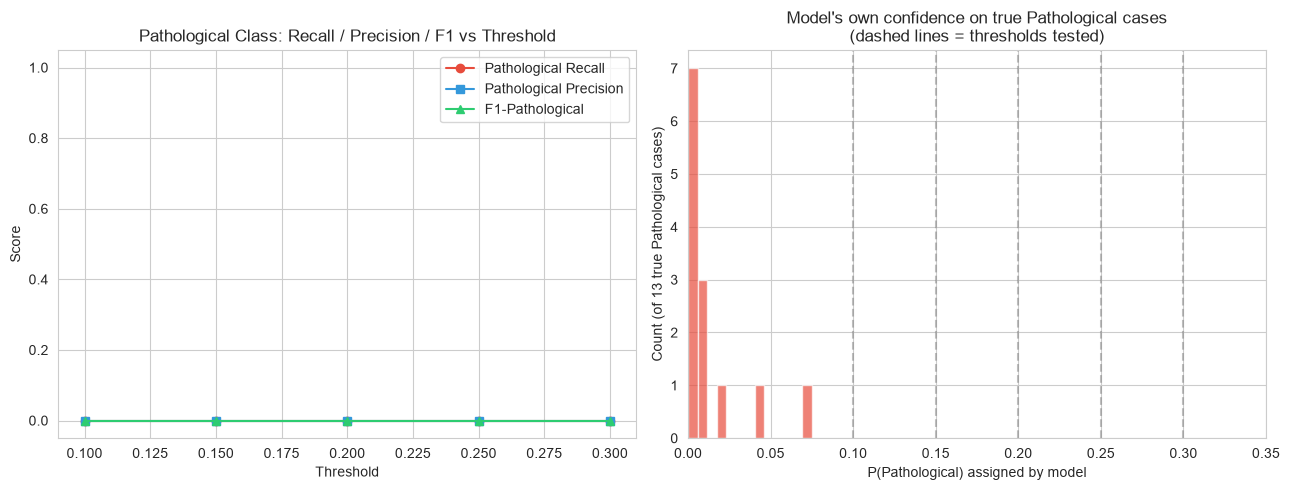

✓ Figure saved: ctu_threshold_sweep.png


In [33]:
display_cols = ["Threshold", "Pathological Recall_mean", "Pathological Precision_mean",
                "F1 - Pathological_mean", "Macro F1_mean", "Accuracy_mean", "MCC_mean"]
display_table = threshold_df[display_cols].copy()
display_table.columns = ["Threshold", "Path. Recall", "Path. Precision",
                         "F1-Pathological", "Macro F1", "Accuracy", "MCC"]
print(display_table.round(4).to_string(index=False))

threshold_df.to_csv("../outputs/evaluation/ctu_threshold_sweep.csv", index=False)
print("\n✓ Saved to outputs/evaluation/ctu_threshold_sweep.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(THRESHOLDS, threshold_df["Pathological Recall_mean"],
            marker="o", label="Pathological Recall", color="#e74c3c")
axes[0].plot(THRESHOLDS, threshold_df["Pathological Precision_mean"],
            marker="s", label="Pathological Precision", color="#3498db")
axes[0].plot(THRESHOLDS, threshold_df["F1 - Pathological_mean"],
            marker="^", label="F1-Pathological", color="#2ecc71")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Pathological Class: Recall / Precision / F1 vs Threshold")
axes[0].legend()
axes[0].set_ylim(-0.05, 1.05)

axes[1].hist(path_true_probs, bins=13, color="#e74c3c", alpha=0.7, label="True Pathological cases")
for t in THRESHOLDS:
    axes[1].axvline(t, color="grey", linestyle="--", alpha=0.5)
axes[1].set_xlabel("P(Pathological) assigned by model")
axes[1].set_ylabel("Count (of 13 true Pathological cases)")
axes[1].set_title("Model's own confidence on true Pathological cases\n(dashed lines = thresholds tested)")
axes[1].set_xlim(0, 0.35)

plt.tight_layout()
plt.savefig("../figures/ctu_threshold_sweep.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Figure saved: ctu_threshold_sweep.png")

## 8. Known Limitations

- **The threshold sweep tested 0.10–0.30; it did not need to go lower to reach a 
  conclusion.** The diagnostic in Section 5 shows the true ceiling directly — the 
  maximum P(Pathological) ever assigned to a genuine Pathological case is 0.0748, 
  meaning thresholds below ~0.08 were the only ones that could technically catch 
  any of these 13 cases. That range was not swept, since values that low would no 
  longer function as a meaningful decision rule — they would sit inside the same 
  probability range the model assigns to ordinary Normal records, trading a small 
  number of true positives for an unquantified number of false positives across 
  the other 539 records. This is a reasoned scope boundary, not an oversight.

- **The small movement in Accuracy (0.6305 → 0.6341) and MCC (0.0891 → 0.0844) 
  across the sweep is not related to Pathological performance** — that stays at 
  exactly 0.0000 recall, precision, and F1 throughout. The movement reflects a 
  handful of borderline Normal/Suspect calls shifting as the threshold changes 
  which records fall into the argmax fallback, not any change in how Pathological 
  is handled.

- **This result is specific to the 10-feature, in-domain CTU-UHB model** trained 
  and evaluated in `07_ctu_external_validation.ipynb`. It should not be read as a 
  general statement that threshold tuning doesn't work for Pathological 
  classification — on the original UCI model (21/13 features, 139 real 
  Pathological training records), the same technique may behave very differently, 
  which is exactly what Mamatha's parallel threshold-tuning work on the UCI model 
  will show. Comparing the two results directly — same technique, two very 
  differently-sized Pathological classes — is a genuinely useful next step once 
  both are done.

- **13 true Pathological records total** means every number reported here — 
  recall, precision, F1, and the probability values in Section 5 — is drawn from 
  an extremely small sample. This was already flagged as a hard ceiling in 07 and 
  is not reintroduced as a new finding here; this notebook confirms it from a 
  third, independent angle (SHAP in 07, raw class count in 07, now threshold/
  probability behaviour here).

## 9. Summary

Threshold tuning was applied to the in-domain CTU-UHB model as a genuine attempt 
to recover Pathological recall, following the same rigour as the SMOTE test 
already reported in `07_ctu_external_validation.ipynb`. It did not work: across 
five thresholds spanning 0.10–0.30, Pathological recall, precision, and F1 remain 
exactly 0.0000 throughout, and the diagnostic probability check shows why — the 
model's own confidence in true Pathological cases tops out at 0.0748, below the 
entire range tested.

This is the third independent line of evidence — alongside the raw 13-record 
class count and the SHAP analysis in 07, both already reported — converging on 
the same conclusion: the 13-record Pathological class is a genuine data-size 
ceiling, not a modelling, resampling, or decision-rule choice that was left 
untried. Two established techniques for addressing exactly this kind of problem 
(SMOTE and threshold tuning) have now both been applied properly and both have 
failed to produce a usable result, for the same underlying reason each time.

The credible path forward remains what 07 already concluded: growing the 
Pathological class in the underlying data. No resampling or decision-rule 
technique can substitute for that.